In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120})

DATA_DIR = Path("../data")
if not DATA_DIR.exists():
    DATA_DIR = Path("Durga/Lab/MLDL/data")

pd.set_option("display.max_columns", 120)

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

df = pd.read_csv(DATA_DIR / "1000_companies.csv", encoding="utf-8-sig")
display(df.head())
display(df.describe(include="all"))

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


,R&D Spend,Administration,Marketing Spend,State,Profit
count,1000.000000,1000.000000,1000.000000,1000,1000.000000
unique,NaN,NaN,NaN,3,NaN
top,NaN,NaN,NaN,California,NaN
freq,NaN,NaN,NaN,344,NaN
mean,81668.927200,122963.897612,226205.058419,NaN,119546.164656
std,46537.567891,12613.927535,91578.393542,NaN,42888.633848
min,0.000000,51283.140000,0.000000,NaN,14681.400000
25%,43084.500000,116640.684850,150969.584600,NaN,85943.198543
50%,79936.000000,122421.612150,224517.887350,NaN,117641.466300
75%,124565.500000,129139.118000,308189.808525,NaN,155577.107425


In [3]:
target = "Profit"
X = df.drop(columns=[target])
y = df[target]

numeric_features = ["R&D Spend", "Administration", "Marketing Spend"]
categorical_features = ["State"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
    ]
)

model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("regressor", LinearRegression()),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

metrics = pd.DataFrame(
    {
        "metric": ["MAE", "RMSE", "R2"],
        "value": [
            mean_absolute_error(y_test, predictions),
            np.sqrt(mean_squared_error(y_test, predictions)),
            r2_score(y_test, predictions),
        ],
    }
)
display(metrics)

,metric,value
0,MAE,1404.437848
1,RMSE,5547.534845
2,R2,0.982528


,feature,coefficient
0,num__R&D Spend,24881.652357
1,num__Administration,13174.603836
2,num__Marketing Spend,7641.483136
3,cat__State_Florida,-874.491486
4,cat__State_New York,-97.133799


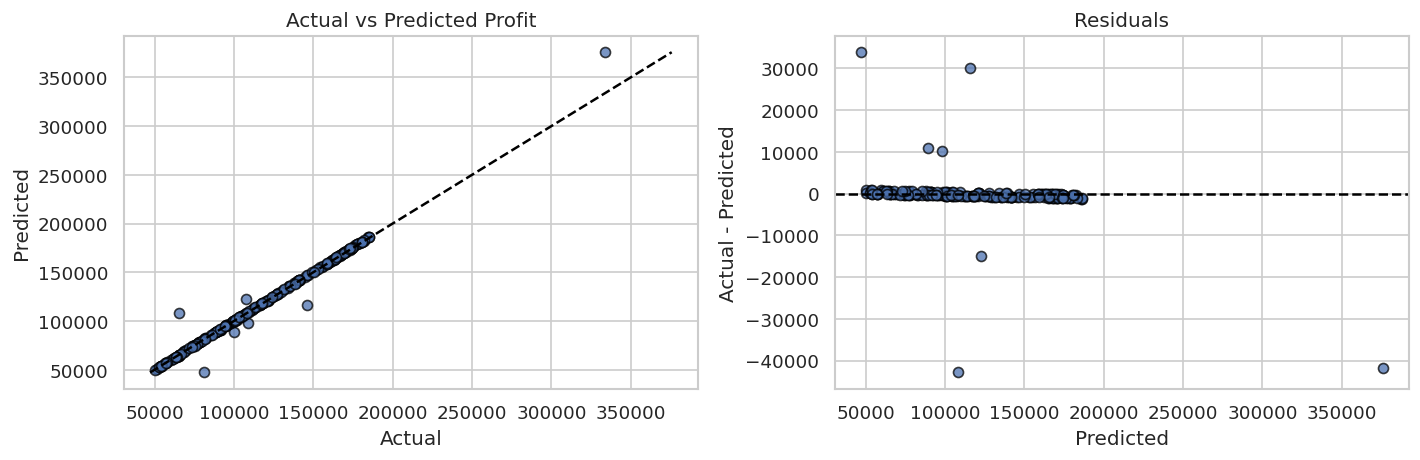

In [4]:
feature_names = model.named_steps["preprocess"].get_feature_names_out()
coef_df = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": model.named_steps["regressor"].coef_,
    }
).sort_values("coefficient", key=lambda s: s.abs(), ascending=False)
display(coef_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_test, predictions, edgecolor="black", alpha=0.75)
lims = [min(y_test.min(), predictions.min()), max(y_test.max(), predictions.max())]
axes[0].plot(lims, lims, color="black", linestyle="--")
axes[0].set_title("Actual vs Predicted Profit")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

residuals = y_test - predictions
axes[1].scatter(predictions, residuals, edgecolor="black", alpha=0.75)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_title("Residuals")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual - Predicted")
plt.tight_layout()
plt.show()